# EDA & Visualization

In [2]:
import pandas as pd, matplotlib.pyplot as plt, requests, seaborn as sns

In [3]:
df = pd.read_csv("../data/raw.csv")

In [4]:
df.head()

,category,location_type,context,outcome_status,persistent_id,id,location_subtype,month,location.latitude,location.street.id,location.street.name,location.longitude,outcome_status.category,outcome_status.date,fetched_month
0,anti-social-behaviour,Force,NaN,NaN,NaN,133811104,NaN,2026-02,53.364714,1712871,On or near Supermarket,-1.507240,NaN,NaN,2026-02
1,anti-social-behaviour,Force,NaN,NaN,NaN,133806613,NaN,2026-02,53.357671,1718143,On or near Willbury Drive,-1.429404,NaN,NaN,2026-02
2,anti-social-behaviour,Force,NaN,NaN,NaN,133803983,NaN,2026-02,53.418961,1717953,On or near Tenterden Road,-1.434182,NaN,NaN,2026-02
3,anti-social-behaviour,Force,NaN,NaN,NaN,133813773,NaN,2026-02,53.366874,1717216,On or near Guildford Avenue,-1.446309,NaN,NaN,2026-02
4,anti-social-behaviour,Force,NaN,NaN,NaN,133813771,NaN,2026-02,53.415489,1716883,On or near Horninglow Road,-1.454976,NaN,NaN,2026-02


In [5]:
print(df.columns.tolist())

['category', 'location_type', 'context', 'outcome_status', 'persistent_id', 'id', 'location_subtype', 'month', 'location.latitude', 'location.street.id', 'location.street.name', 'location.longitude', 'outcome_status.category', 'outcome_status.date', 'fetched_month']


In [6]:
df = df.rename(columns={
    "location.latitude":     "latitude",
    "location.longitude":    "longitude",
    "location.street.name":  "street",
    "outcome_status.category": "outcome",
})

df.columns.tolist()  # confirm the rename worked


['category',
 'location_type',
 'context',
 'outcome_status',
 'persistent_id',
 'id',
 'location_subtype',
 'month',
 'latitude',
 'location.street.id',
 'street',
 'longitude',
 'outcome',
 'outcome_status.date',
 'fetched_month']

In [7]:
df["latitude"]  = pd.to_numeric(df["latitude"],  errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

# check how many went null after conversion
print(f"Null latitudes:  {df['latitude'].isnull().sum()}")
print(f"Null longitudes: {df['longitude'].isnull().sum()}")


Null latitudes:  0
Null longitudes: 0


In [8]:
before = len(df)

df = df[
    (df["latitude"].between(53.30, 53.47)) &
    (df["longitude"].between(-1.60, -1.30))
]

print(f"Dropped {before - len(df)} records outside Sheffield")
print(f"Remaining: {len(df)}")


Dropped 0 records outside Sheffield
Remaining: 83530


In [9]:
df["date"]    = pd.to_datetime(df["month"])
df["year"]    = df["date"].dt.year
df["month_n"] = df["date"].dt.month
df["season"]  = df["month_n"].map({
    12:"Winter", 1:"Winter",  2:"Winter",
    3:"Spring",  4:"Spring",  5:"Spring",
    6:"Summer",  7:"Summer",  8:"Summer",
    9:"Autumn",  10:"Autumn", 11:"Autumn"
})

df[["month", "date", "year", "month_n", "season"]].head(10)


,month,date,year,month_n,season
0,2026-02,2026-02-01,2026,2,Winter
1,2026-02,2026-02-01,2026,2,Winter
2,2026-02,2026-02-01,2026,2,Winter
3,2026-02,2026-02-01,2026,2,Winter
4,2026-02,2026-02-01,2026,2,Winter
5,2026-02,2026-02-01,2026,2,Winter
6,2026-02,2026-02-01,2026,2,Winter
7,2026-02,2026-02-01,2026,2,Winter
8,2026-02,2026-02-01,2026,2,Winter
9,2026-02,2026-02-01,2026,2,Winter


In [10]:
print("Shape:", df.shape)
print("\nCategories:")
print(df["category"].value_counts())
print("\nYear range:", df["year"].min(), "–", df["year"].max())
print("\nNull check:")
print(df[["latitude","longitude","category","month","season"]].isnull().sum())


Shape: (83530, 19)

Categories:
category
violent-crime            25964
anti-social-behaviour    13440
shoplifting               8503
public-order              6305
criminal-damage-arson     6181
vehicle-crime             5590
other-theft               4489
burglary                  4152
drugs                     3131
other-crime               2306
possession-of-weapons     1038
robbery                    960
theft-from-the-person      875
bicycle-theft              596
Name: count, dtype: int64

Year range: 2024 – 2026

Null check:
latitude     0
longitude    0
category     0
month        0
season       0
dtype: int64


In [11]:
import sqlite3

In [12]:
df.to_csv("../data/clean.csv", index=False)
conn = sqlite3.connect("../data/crime.db")
df.to_sql("crime", conn, if_exists="replace", index=False)
conn.close()

print(f"Saved {len(df)} clean records to CSV and SQLite")

Saved 83530 clean records to CSV and SQLite


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# plot styling
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "sans-serif"
})

df = pd.read_csv("../data/clean.csv", parse_dates=["date"])
print(f"Records: {len(df):,}")
print(f"Date range: {df['month'].min()} to {df['month'].max()}")
df.head()


Records: 83,530
Date range: 2024-09 to 2026-02


,category,location_type,context,outcome_status,persistent_id,id,location_subtype,month,latitude,location.street.id,street,longitude,outcome,outcome_status.date,fetched_month,date,year,month_n,season
0,anti-social-behaviour,Force,NaN,NaN,NaN,133811104,NaN,2026-02,53.364714,1712871,On or near Supermarket,-1.507240,NaN,NaN,2026-02,2026-02-01,2026,2,Winter
1,anti-social-behaviour,Force,NaN,NaN,NaN,133806613,NaN,2026-02,53.357671,1718143,On or near Willbury Drive,-1.429404,NaN,NaN,2026-02,2026-02-01,2026,2,Winter
2,anti-social-behaviour,Force,NaN,NaN,NaN,133803983,NaN,2026-02,53.418961,1717953,On or near Tenterden Road,-1.434182,NaN,NaN,2026-02,2026-02-01,2026,2,Winter
3,anti-social-behaviour,Force,NaN,NaN,NaN,133813773,NaN,2026-02,53.366874,1717216,On or near Guildford Avenue,-1.446309,NaN,NaN,2026-02,2026-02-01,2026,2,Winter
4,anti-social-behaviour,Force,NaN,NaN,NaN,133813771,NaN,2026-02,53.415489,1716883,On or near Horninglow Road,-1.454976,NaN,NaN,2026-02,2026-02-01,2026,2,Winter


In [15]:
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())


Shape: (83530, 19)

Dtypes:
category                          str
location_type                     str
context                       float64
outcome_status                float64
persistent_id                     str
id                              int64
location_subtype                  str
month                             str
latitude                      float64
location.street.id              int64
street                            str
longitude                     float64
outcome                           str
outcome_status.date               str
fetched_month                     str
date                   datetime64[us]
year                            int64
month_n                         int64
season                            str
dtype: object

Missing values:
category                   0
location_type              0
context                83530
outcome_status         83530
persistent_id          13505
id                         0
location_subtype       83465
month           

## Crime by Category — Sheffield

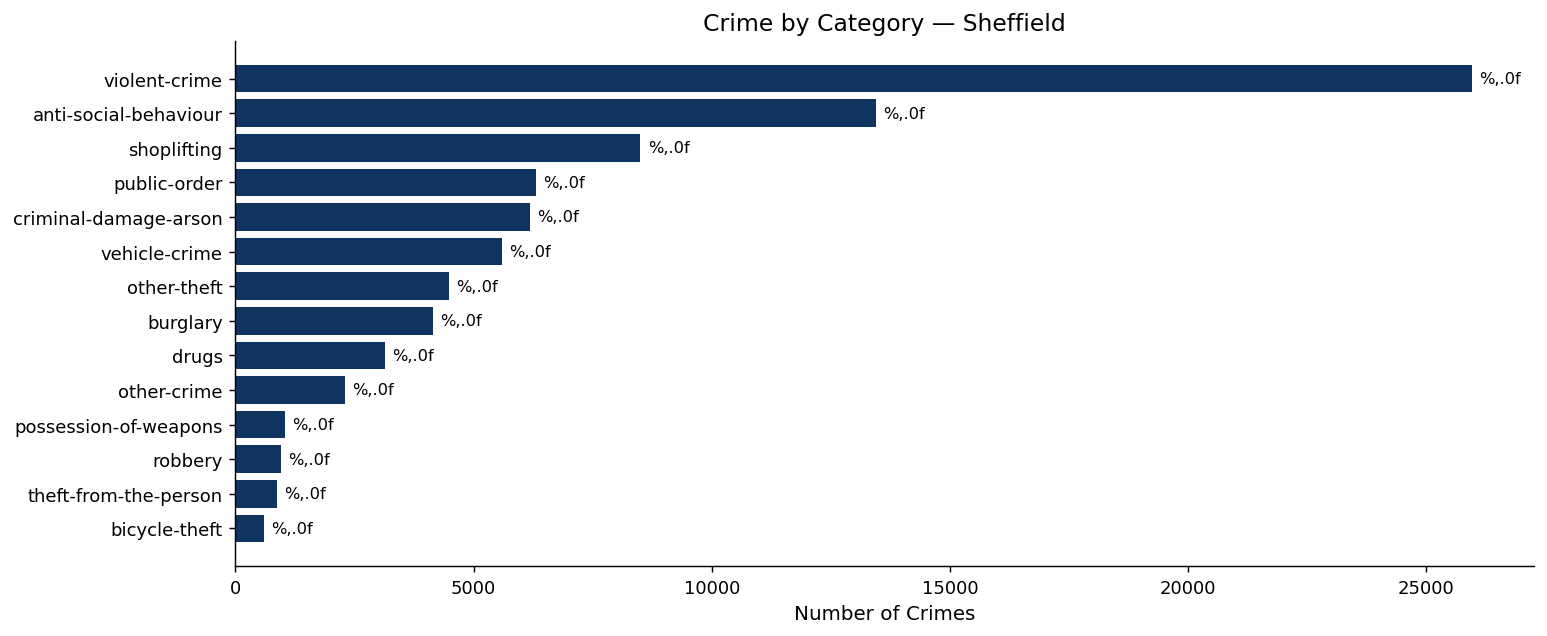

category
violent-crime            25964
anti-social-behaviour    13440
shoplifting               8503
public-order              6305
criminal-damage-arson     6181
vehicle-crime             5590
other-theft               4489
burglary                  4152
drugs                     3131
other-crime               2306
possession-of-weapons     1038
robbery                    960
theft-from-the-person      875
bicycle-theft              596
Name: count, dtype: int64


In [17]:
cat_counts = df["category"].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(cat_counts.index, cat_counts.values, color="#0f3460")
ax.bar_label(bars, fmt="%,.0f", padding=4, fontsize=9)
ax.set_xlabel("Number of Crimes")
ax.set_title("Crime by Category — Sheffield")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../data/fig_categories.png", dpi=150, bbox_inches="tight")
plt.show()
print(cat_counts)


## Monthly Crime Trend(overall)

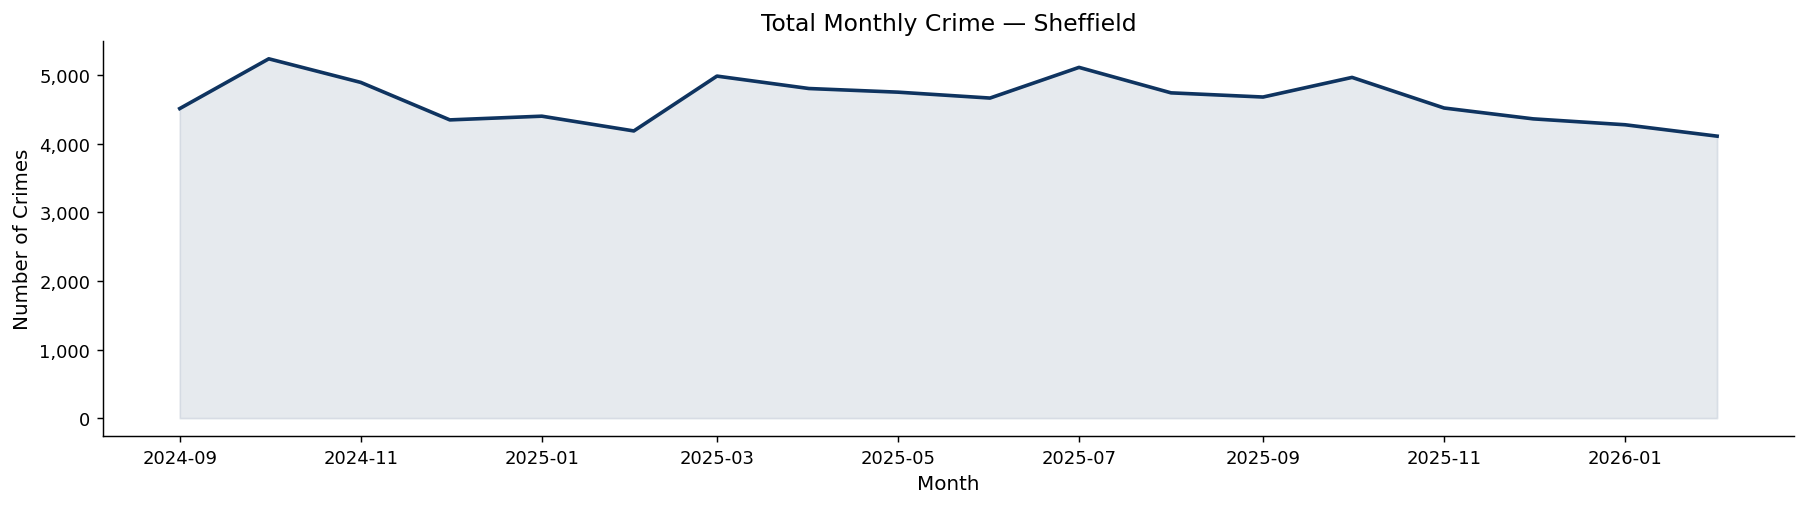

In [18]:
monthly = df.groupby("month").size().reset_index(name="count")
monthly["month"] = pd.to_datetime(monthly["month"])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly["month"], monthly["count"], color="#0f3460", linewidth=2)
ax.fill_between(monthly["month"], monthly["count"], alpha=0.1, color="#0f3460")
ax.set_title("Total Monthly Crime — Sheffield")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Crimes")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../data/fig_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()


## Monthly Trend by Top 6 Crime Types

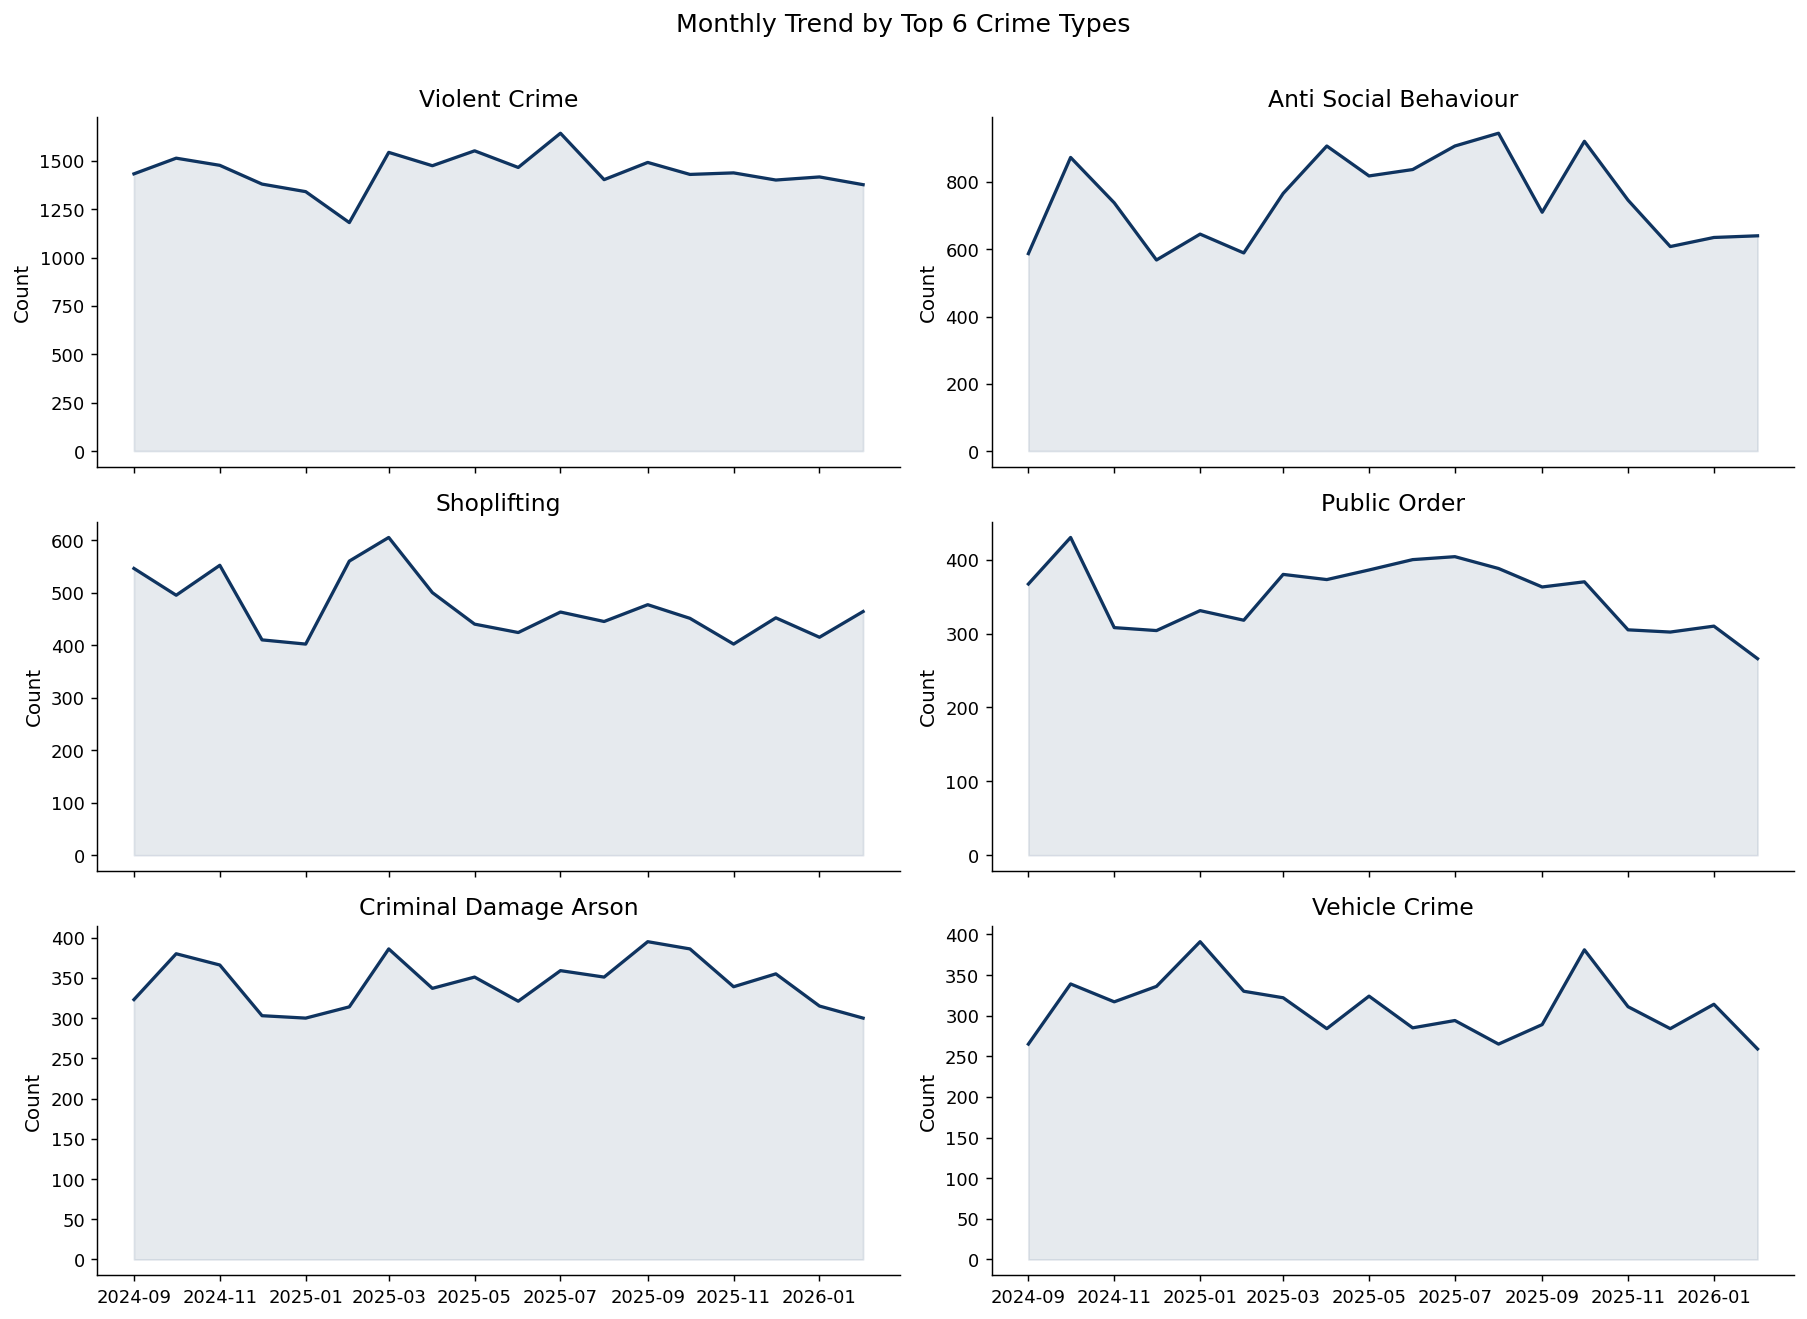

In [20]:
# top 6 categories only to keep it readable
top6 = df["category"].value_counts().head(6).index.tolist()
df_top = df[df["category"].isin(top6)]

monthly_cat = df_top.groupby(["month", "category"]).size().reset_index(name="count")
monthly_cat["month"] = pd.to_datetime(monthly_cat["month"])

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for i, cat in enumerate(top6):
    subset = monthly_cat[monthly_cat["category"] == cat]
    axes[i].plot(subset["month"], subset["count"], color="#0f3460", linewidth=1.8)
    axes[i].fill_between(subset["month"], subset["count"], alpha=0.1, color="#0f3460")
    axes[i].set_title(cat.replace("-", " ").title())
    axes[i].set_ylabel("Count")

plt.suptitle("Monthly Trend by Top 6 Crime Types", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../data/fig_trend_by_category.png", dpi=150, bbox_inches="tight")
plt.show()


## Crime by Season 

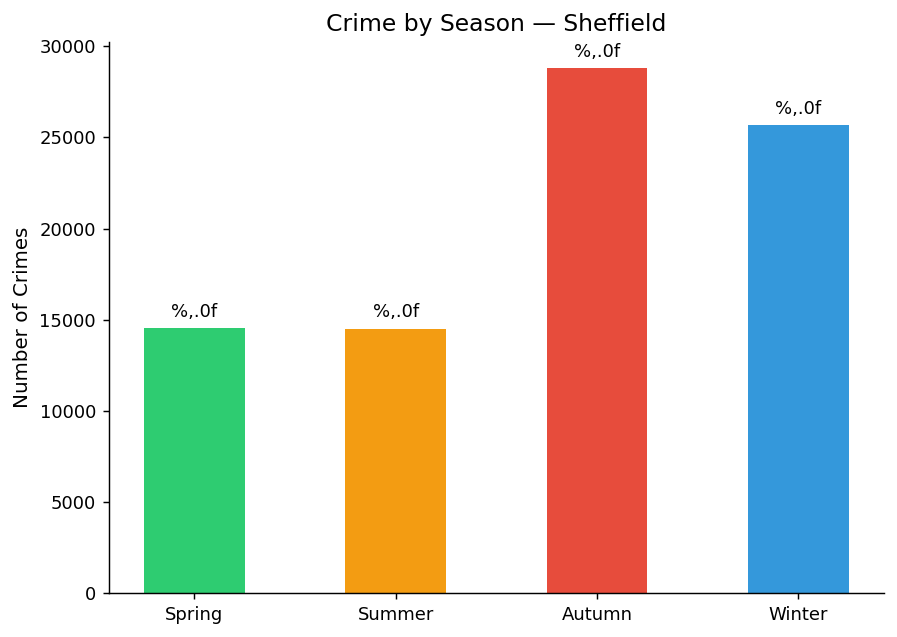

In [22]:
season_order = ["Spring", "Summer", "Autumn", "Winter"]
season_counts = df["season"].value_counts().reindex(season_order)

colors = ["#2ecc71", "#f39c12", "#e74c3c", "#3498db"]
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(season_counts.index, season_counts.values, color=colors, width=0.5)
ax.bar_label(bars, fmt="%,.0f", padding=4)
ax.set_title("Crime by Season — Sheffield")
ax.set_ylabel("Number of Crimes")
plt.tight_layout()
plt.savefig("../data/fig_season.png", dpi=150, bbox_inches="tight")
plt.show()


## T

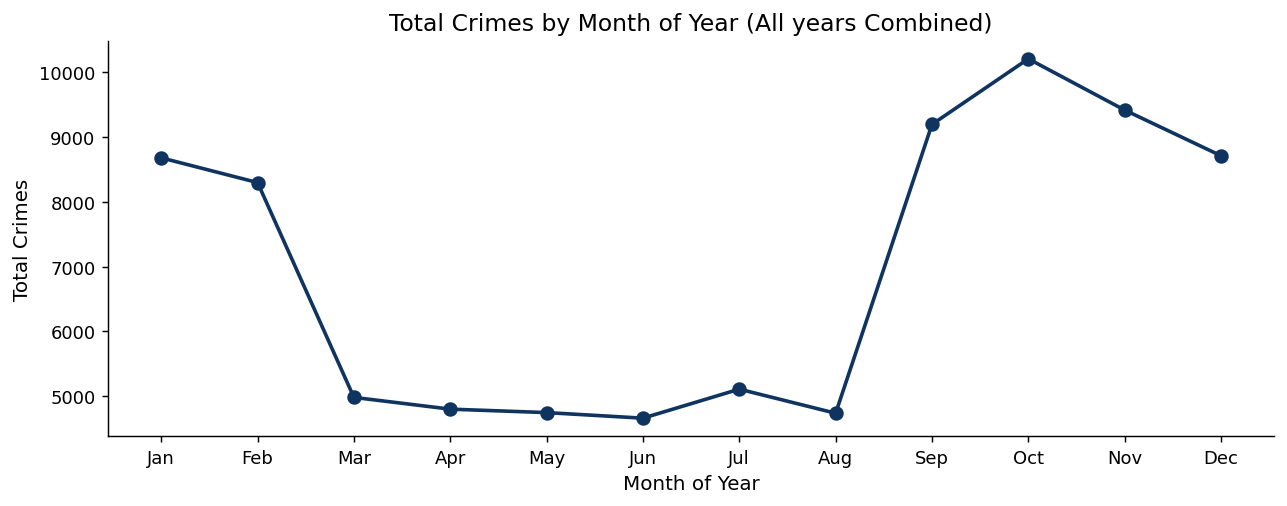

In [31]:
month_avg = df.groupby("month_n").size().reset_index(name="count")
month_name = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_avg["month_name"] = month_avg["month_n"].apply(lambda x: month_name[x-1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(month_avg["month_name"],month_avg["count"], 
        marker="o", color="#0f3460", linewidth=2, markersize=7)

ax.set_title("Total Crimes by Month of Year (All years Combined)")
ax.set_xlabel("Month of Year")
ax.set_ylabel("Total Crimes")
plt.tight_layout()
plt.savefig("../data/fig_avg_by_month.png", dpi=150, bbox_inches="tight")
plt.show()

## Crime by month of year (seasonality pattern)

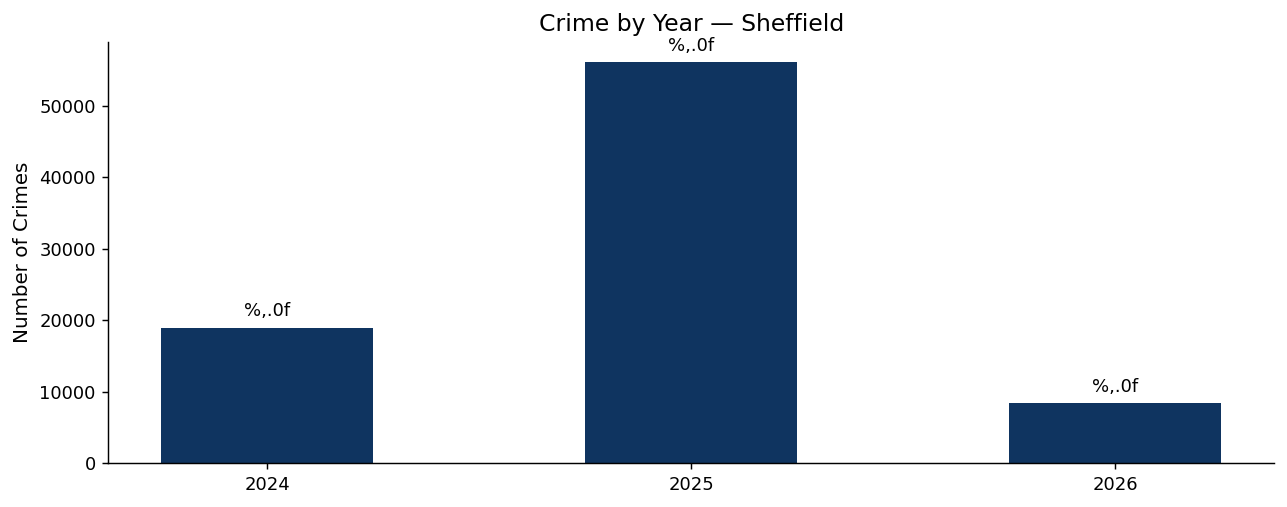

In [34]:
yearly = df.groupby("year").size().reset_index(name="count")

fig,ax = plt.subplots(figsize=(10,4))
bar = ax.bar(yearly["year"].astype(str), yearly["count"], color="#0f3460", width=0.5)
ax.bar_label(bar, fmt="%,.0f", padding=4)
ax.set_title("Crime by Year — Sheffield")
ax.set_ylabel("Number of Crimes")
plt.tight_layout()
plt.savefig("../data/fig_yearly.png", dpi=150, bbox_inches="tight")
plt.show()

## Heatmap: crime type vs month of Year

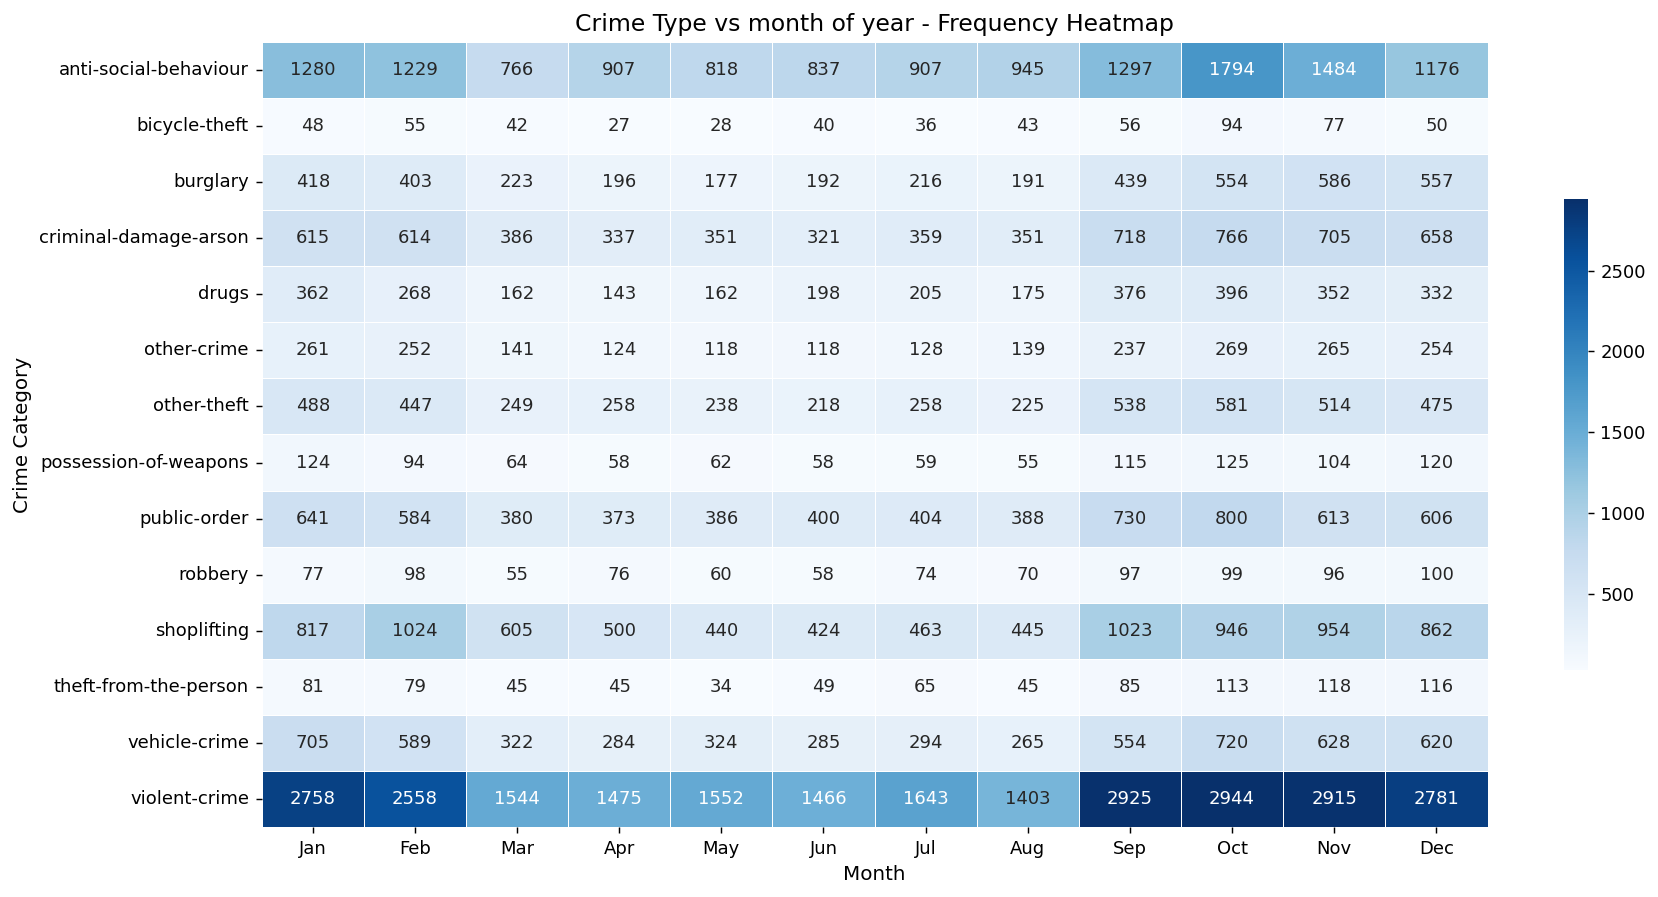

In [38]:
pivot = df.groupby(["category", "month_n"]).size().unstack(fill_value=0)
pivot.columns = month_name

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot, annot=True, fmt="d", cmap="Blues",
    linewidths=0.4, ax=ax, cbar_kws={"shrink": 0.6}
    
)

ax.set_title("Crime Type vs month of year - Frequency Heatmap")
ax.set_xlabel("Month")
ax.set_ylabel("Crime Category")
plt.tight_layout()
plt.savefig("../data/fig_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Geographic Distribution

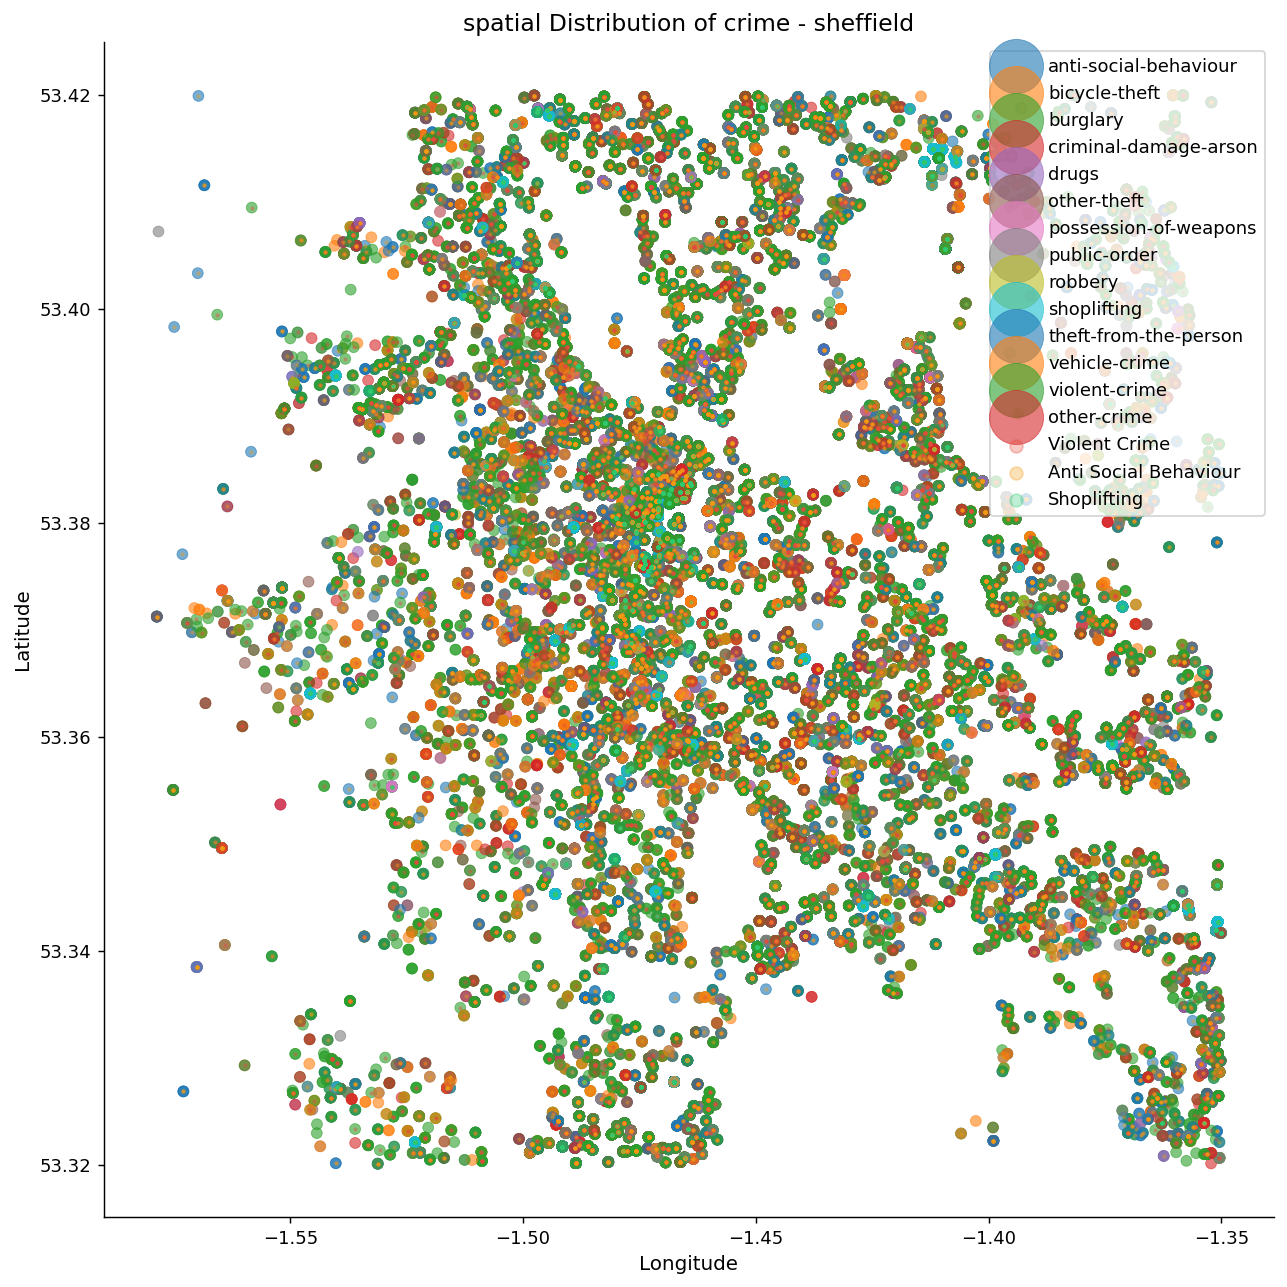

In [42]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.scatterplot(
    data=df, x="longitude", y="latitude",
    hue="category", palette="tab10", alpha=0.6, edgecolor=None, ax=ax
)

colors_map ={
    top6[0]: "#e74c3c",
    top6[1]: "#f39c12",
    top6[2]: "#2ecc71"
}

for cat, col in colors_map.items():
    sub = df[df["category"] == cat]
    ax.scatter(sub["longitude"], sub["latitude"], label=cat.replace("-", " ").title(), color=col, alpha=0.3, s=2, edgecolor=None)
    
ax.set_title("spatial Distribution of crime - sheffield")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(markerscale= 5, loc="upper right")
plt.tight_layout()
plt.savefig("../data/fig_spatial.png", dpi=150, bbox_inches="tight")
plt.show()
    

## outcome analysis

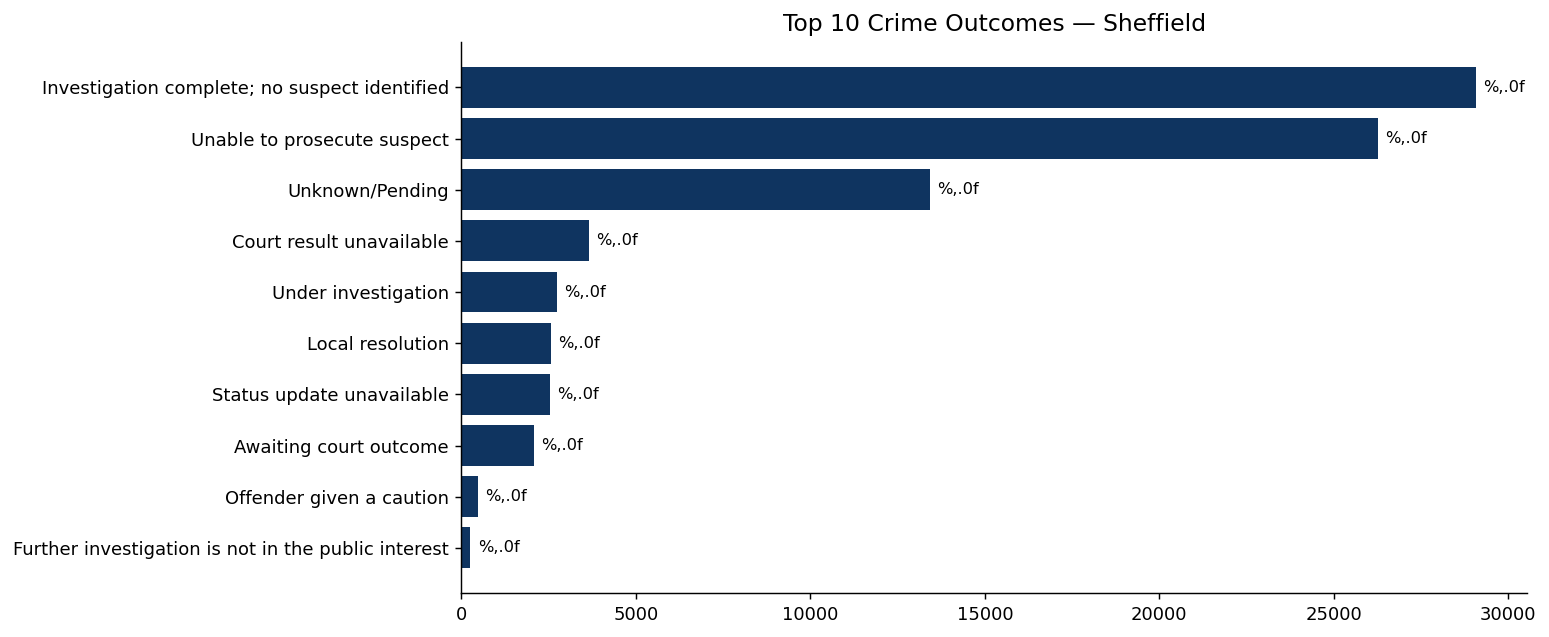

In [44]:
if "outcome" in df.columns:
    outcome_counts = df["outcome"].fillna("Unknown/Pending").value_counts().head(10)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.barh(outcome_counts.index, outcome_counts.values, color="#0f3460")
    ax.bar_label(bars, fmt="%,.0f", padding=4, fontsize=9)
    ax.set_title("Top 10 Crime Outcomes — Sheffield")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig("../data/fig_outcomes.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No outcome column in dataset")


## Summary Statistics Table

In [45]:
summary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Date range",
        "Unique crime categories",
        "Most common crime",
        "Least common crime",
        "Peak month",
        "Quietest month",
        "Lat range",
        "Lon range",
    ],
    "Value": [
        f"{len(df):,}",
        f"{df['month'].min()} to {df['month'].max()}",
        str(df["category"].nunique()),
        df["category"].value_counts().idxmax().replace("-"," ").title(),
        df["category"].value_counts().idxmin().replace("-"," ").title(),
        df.groupby("month").size().idxmax(),
        df.groupby("month").size().idxmin(),
        f"{df['latitude'].min():.4f} – {df['latitude'].max():.4f}",
        f"{df['longitude'].min():.4f} – {df['longitude'].max():.4f}",
    ]
})

summary


,Metric,Value
0,Total records,"83,530"
1,Date range,2024-09 to 2026-02
2,Unique crime categories,14
3,Most common crime,Violent Crime
4,Least common crime,Bicycle Theft
5,Peak month,2024-10
6,Quietest month,2026-02
7,Lat range,53.3201 – 53.4200
8,Lon range,-1.5787 – -1.3501


In [46]:
import os 
figs = [f for f in os.listdir("../data/") if f.startswith("fig_") and f.endswith(".png")]
print(f"Saved figures: {len(figs)} figures:")
for f in sorted(figs):
    print(f" ../data/{f}")

Saved figures: 9 figures:
 ../data/fig_avg_by_month.png
 ../data/fig_categories.png
 ../data/fig_heatmap.png
 ../data/fig_monthly_trend.png
 ../data/fig_outcomes.png
 ../data/fig_season.png
 ../data/fig_spatial.png
 ../data/fig_trend_by_category.png
 ../data/fig_yearly.png
